In [1]:
from model_driver import driver
from iotools import read_results
import pandas as pd
from dotenv import load_dotenv
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pathlib
load_dotenv()

project_folder = Path(os.getenv('PROJECT_FOLDER'))
input_folder = os.path.join(project_folder, 'model_inputs')

%matplotlib widget

In [2]:
# runs model
outputfile = driver(create_ncf=True, folder=input_folder, param_module="parameters_ad")

# reads results from .nc-file
results = read_results(outputfile)

*** Running model ***


c:\dev\Git_repos\SpaFHy_Peat_AD\canopygrid.py:584: RuntimeWarning: divide by zero encountered in divide
  ustar = Uo * kv / np.log((zm - d) / zom)
c:\dev\Git_repos\SpaFHy_Peat_AD\canopygrid.py:585: RuntimeWarning: invalid value encountered in divide
  Uh = ustar / kv * np.log((hc - d) / zom)
c:\dev\Git_repos\SpaFHy_Peat_AD\canopygrid.py:588: RuntimeWarning: divide by zero encountered in divide
  zn = np.minimum(zg / hc, 1.0)  # zground can't be above canopy top
c:\dev\Git_repos\SpaFHy_Peat_AD\canopygrid.py:593: RuntimeWarning: divide by zero encountered in divide
  ra = 1./(kv**2.0 * Uo) * np.log((zm - d) / zom) * np.log((zm - d) / zov)


*** Writing results to netCDF4-file, subset 1/30 ***
*** Writing results to netCDF4-file, subset 2/30 ***
*** Writing results to netCDF4-file, subset 3/30 ***
*** Writing results to netCDF4-file, subset 4/30 ***
*** Writing results to netCDF4-file, subset 5/30 ***
*** Writing results to netCDF4-file, subset 6/30 ***
*** Writing results to netCDF4-file, subset 7/30 ***
*** Writing results to netCDF4-file, subset 8/30 ***
*** Writing results to netCDF4-file, subset 9/30 ***
*** Writing results to netCDF4-file, subset 10/30 ***
*** Writing results to netCDF4-file, subset 11/30 ***
*** Writing results to netCDF4-file, subset 12/30 ***
*** Writing results to netCDF4-file, subset 13/30 ***
*** Writing results to netCDF4-file, subset 14/30 ***
*** Writing results to netCDF4-file, subset 15/30 ***
*** Writing results to netCDF4-file, subset 16/30 ***
*** Writing results to netCDF4-file, subset 17/30 ***
*** Writing results to netCDF4-file, subset 18/30 ***
*** Writing results to netCDF4-file, 

c:\dev\Git_repos\SpaFHy_Peat_AD\iotools.py:499: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  result.coords['i'] = -np.arange(0,result.dims['i'])
c:\dev\Git_repos\SpaFHy_Peat_AD\iotools.py:500: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  result.coords['j'] = np.arange(0,result.dims['j'])


In [3]:
# outputfile = input_folder + '/results202603111127.nc'
results = read_results(outputfile)

c:\dev\Git_repos\SpaFHy_Peat_AD\iotools.py:499: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  result.coords['i'] = -np.arange(0,result.dims['i'])
c:\dev\Git_repos\SpaFHy_Peat_AD\iotools.py:500: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  result.coords['j'] = np.arange(0,result.dims['j'])


In [4]:
results

<xarray.Dataset> Size: 39MB
Dimensions:                   (i: 442, j: 2, date: 10958)
Coordinates:
  * i                         (i) int64 4kB 0 -1 -2 -3 ... -438 -439 -440 -441
  * j                         (j) int64 16B 0 1
  * date                      (date) datetime64[ns] 88kB 1996-01-01 ... 2025-...
Data variables:
    parameters_lai_conif      (i, j) float32 4kB ...
    parameters_lai_decid_max  (i, j) float32 4kB ...
    parameters_cf             (i, j) float32 4kB ...
    parameters_soilclass      (i, j) float32 4kB ...
    parameters_ditch_depth    (i, j) float32 4kB ...
    parameters_ditch_spacing  (i, j) float32 4kB ...
    parameters_lat            (i, j) float32 4kB ...
    parameters_lon            (i, j) float32 4kB ...
    soil_ground_water_level   (date, i, j) float32 39MB ...
Attributes:
    description:  SpaFHy results : testcase
    history:      created 2026-04-23 11:22:17
    source:       modified SpaFHy v.1.0

In [5]:
# Select june-august data
summer = results['soil_ground_water_level'].sel(
    date=results['soil_ground_water_level'].date.dt.month.isin([6, 7, 8])
)

# Group by year and calculate summer mean for each year
summer_mean_by_year = summer.groupby('date.year').mean(dim='date')

# For real and adapt scenarios
real_mean_by_year = summer_mean_by_year.sel(j=0)
adapt_mean_by_year = summer_mean_by_year.sel(j=1)

# Overall mean across all years
real_overall_mean = real_mean_by_year.mean(dim='year').values
adapt_overall_mean = adapt_mean_by_year.mean(dim='year').values

# 10th and 90th percentile across all years
real_q10 = real_mean_by_year.quantile(0.1, dim='year').values
real_q90 = real_mean_by_year.quantile(0.9, dim='year').values

adapt_q10 = adapt_mean_by_year.quantile(0.1, dim='year').values
adapt_q90 = adapt_mean_by_year.quantile(0.9, dim='year').values

c:\dev\Git_repos\SpaFHy_Peat_AD\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [6]:

from collections import Counter

def get_soil_profile_info(soil_ids, peat_dict):
    peat_layers = []
    dominant_mineral = []

    for sid in soil_ids:
        key = f"soil_{int(sid)}"

        soil = peat_dict[key]
        soil_types = soil["soil_types"]

        # Count peat layers
        peat_layers.append(sum(t.startswith("Peat") for t in soil_types))

        # Filter mineral types
        mineral_types = [t for t in soil_types if t in ["Fine", "Coarse", "Medium"]]

        # Most common mineral type
        dom_mineral = 'Peat_only'
        if mineral_types:
            dom_mineral = Counter(mineral_types).most_common(1)[0][0]

        dominant_mineral.append(dom_mineral)

    return np.array(peat_layers), np.array(dominant_mineral)

from parameters_ad import peat_soilprofiles

peatp = peat_soilprofiles()

soil_ids = results['parameters_soilclass'][:,0].values
peat_layers, dominant_mineral = get_soil_profile_info(soil_ids, peatp)

dominant_mineral_numeric = np.zeros_like(dominant_mineral, dtype=float)
for i, val in enumerate(dominant_mineral):
    if val == 'Peat_only':
        dominant_mineral_numeric[i] = 0
    elif val == 'Fine':
        dominant_mineral_numeric[i] = 1
    elif val == 'Medium':
        dominant_mineral_numeric[i] = 2
    elif val == 'Coarse':
        dominant_mineral_numeric[i] = 3


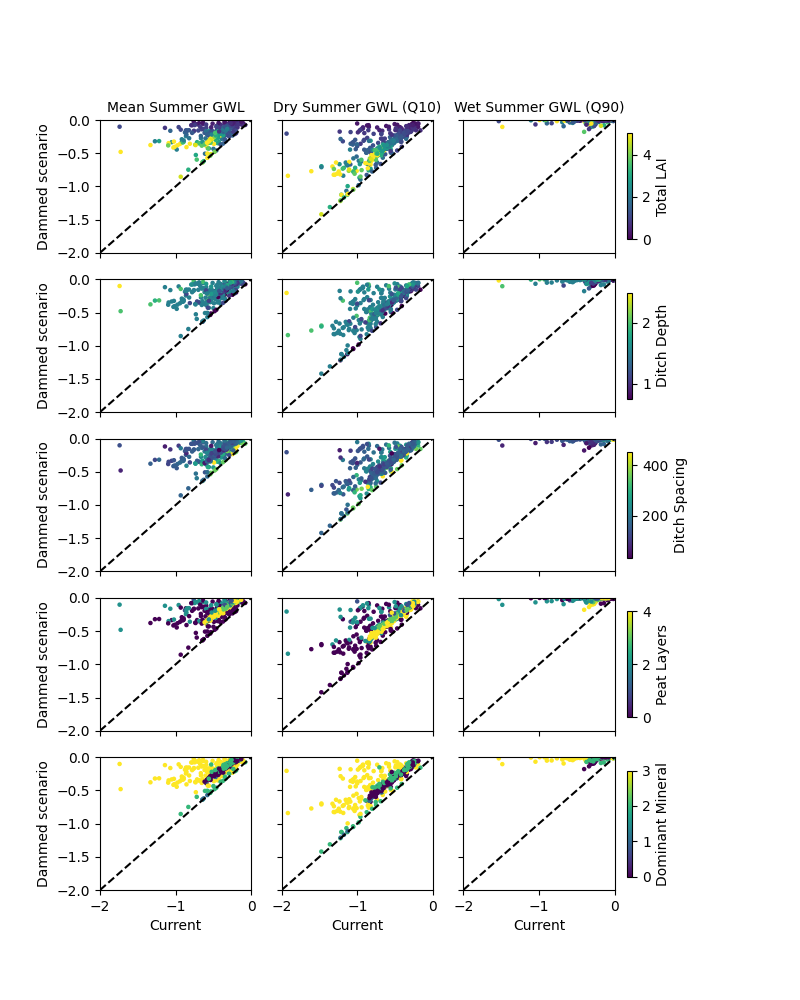

In [7]:

# Calculate total LAI
total_lai = results['parameters_lai_conif'][:,0] + results['parameters_lai_decid_max'][:,0]
soil_id = results['parameters_soilclass'][:,0]
ditch_depth = results['parameters_ditch_depth'][:,0]
ditch_spacing = results['parameters_ditch_spacing'][:,0]

color_vars = [total_lai, ditch_depth, ditch_spacing, peat_layers, dominant_mineral_numeric]
color_labels = ['Total LAI', 'Ditch Depth', 'Ditch Spacing', 'Peat Layers', 'Dominant Mineral']

fig, axes = plt.subplots(len(color_vars), 3, figsize=(8, 10), sharex=True, sharey=True)

for row, (color_var, color_label) in enumerate(zip(color_vars, color_labels)):
    # Fix color scale only for Total LAI row
    scatter_kwargs = {}
    if color_label == 'Total LAI':
        scatter_kwargs = {"vmin": 0, "vmax": 5}

    # Plot mean
    scatter0 = axes[row, 0].scatter(real_overall_mean, adapt_overall_mean, c=color_var, s=5, **scatter_kwargs)
    axes[row, 0].axline((0, 0), slope=1, linestyle='--', color='black')
    axes[row, 0].set_ylabel("Dammed scenario")
    if row == 0:
        axes[row, 0].set_title("Mean Summer GWL", fontsize=10)
    if row == len(color_vars) - 1:
        axes[row, 0].set_xlabel("Current")
    axes[row, 0].set_ylim([-2., 0.])
    axes[row, 0].set_xlim([-2., 0.])

    # Plot Q10
    scatter1 = axes[row, 1].scatter(real_q10, adapt_q10, c=color_var, s=5, **scatter_kwargs)
    axes[row, 1].axline((0, 0), slope=1, linestyle='--', color='black')
    if row == 0:
        axes[row, 1].set_title("Dry Summer GWL (Q10)", fontsize=10)
    if row == len(color_vars) - 1:
        axes[row, 1].set_xlabel("Current")
    axes[row, 1].set_ylim([-2., 0.])
    axes[row, 1].set_xlim([-2., 0.])

    # Plot Q90
    scatter2 = axes[row, 2].scatter(real_q90, adapt_q90, c=color_var, s=5, **scatter_kwargs)
    axes[row, 2].axline((0, 0), slope=1, linestyle='--', color='black')
    if row == 0:
        axes[row, 2].set_title("Wet Summer GWL (Q90)", fontsize=10)
    if row == len(color_vars) - 1:
        axes[row, 2].set_xlabel("Current")
    axes[row, 2].set_ylim([-2., 0.])
    axes[row, 2].set_xlim([-2., 0.])

    # Add colorbar for each row (will use the same mappable as the right-most scatter)
    cbar = plt.colorbar(scatter2, ax=axes[row, :], label=color_label, shrink=0.8, pad=0.02)

#plt.savefig(project_folder / 'model_inputs' / 'figures' / 'scatters_colors.png', dpi=150, bbox_inches = 'tight')


# Get dominant trees

In [13]:
LAI_folder = pathlib.Path(os.getenv('PROJECT_FOLDER') + '/model_inputs/LAI_cf/')
LAI_est = pd.read_csv(LAI_folder/'EST_LAI_capped_to_10_cf_extra.csv')
LAI_lat = pd.read_csv(LAI_folder/'LAT_LAI_cf.csv')

print(len(LAI_est),len(LAI_lat))

344 98


In [14]:
# Get dominant tree name for each row
#Est
lai_cols_est = [
    "LAI_spruce",
    "LAI_pine",
    "LAI_birch",
    "LAI_aspen",
    "LAI_grey_alder",
    "LAI_black_alder",
]

LAI_est = LAI_est.assign(LAI_max_label=LAI_est[lai_cols_est].idxmax(axis=1))
LAI_est['LAI_max_label'] = LAI_est['LAI_max_label'].apply(lambda x: " ".join(x.split('_')[1:]))

#lat
lai_cols_lat = [
    "LAI_spruce",
    "LAI_pine",
    "LAI_birch",
]
LAI_lat = LAI_lat.assign(LAI_max_label=LAI_lat[lai_cols_lat].idxmax(axis=1))
LAI_lat['LAI_max_label'] = LAI_lat['LAI_max_label'].apply(lambda x: x.split('_')[1])

LAI_lat[lai_cols_lat]

,LAI_spruce,LAI_pine,LAI_birch
0,0.304278,0.087379,0.838855
1,0.197371,0.060739,0.572394
2,0.140905,0.037399,0.616872
3,1.756578,0.086928,0.753289
4,0.368864,0.081922,0.708943
...,...,...,...
93,0.582963,0.018653,0.086583
94,0.323984,0.080312,0.010336
95,0.311317,0.071766,0.048289
96,0.073429,0.513198,0.035821


In [15]:
# Get dominant tree name for each row
#Est
ba_cols_est = [
    "BA_spruce",
    "BA_pine",
    "BA_birch",
    "BA_aspen",
    "BA_grey_alder",
    "BA_black_alder",
]

LAI_est = LAI_est.assign(BA_max_label=LAI_est[ba_cols_est].idxmax(axis=1))
LAI_est['BA_max_label'] = LAI_est['BA_max_label'].apply(lambda x: " ".join(x.split('_')[1:]))

#lat
ba_cols_lat = [
    "BA_spruce",
    "BA_pine",
    "BA_birch",
]
LAI_lat = LAI_lat.assign(BA_max_label=LAI_lat[ba_cols_lat].idxmax(axis=1))
LAI_lat['BA_max_label'] = LAI_lat['BA_max_label'].apply(lambda x: x.split('_')[1])

In [16]:
LAI_df = pd.concat((LAI_est, LAI_lat), ignore_index=True)

BA_max_label_numeric = np.zeros_like(LAI_df['BA_max_label'], dtype=float)
for i, val in enumerate(LAI_df['BA_max_label']):
    if val == 'spruce':
        BA_max_label_numeric[i] = 0
    elif val == 'pine':
        BA_max_label_numeric[i] = 1
    elif val == 'birch':
        BA_max_label_numeric[i] = 2
    else:
        BA_max_label_numeric[i] = 3

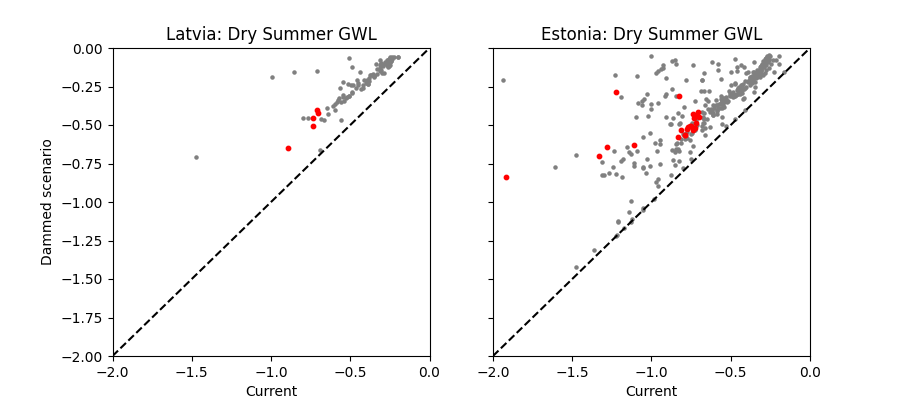

In [17]:
# Create categorical color variable based on latitude
lat = results['parameters_lat'][:,0]
lon = results['parameters_lon'][:,0]
color_var = np.where(lat > 57, 1, 0)  # 1 for lat > 57, 0 for lat <= 57

# Create separate indices for each category
idx_latvia = color_var == 0
idx_estonia = color_var == 1

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

# Selection criteria
ix_latvia = idx_latvia & (real_q10 < -0.7) & (real_q10 - adapt_q10 < -0.2) & (total_lai > 1.5) & (BA_max_label_numeric == 0) & (peat_layers >= 2)
ix_estonia = idx_estonia & (real_q10 < -0.7) & (real_q10 - adapt_q10 < -0.2) & (total_lai > 1.5) & (BA_max_label_numeric == 0) & (peat_layers >= 2)

for ax, idx, ix, country in zip(axes, [idx_latvia, idx_estonia], [ix_latvia, ix_estonia], ['Latvia', 'Estonia']):
    # Plot mean
    scatter0 = ax.scatter(real_q10[idx], adapt_q10[idx], c='grey', s=5)
    scatter0 = ax.scatter(real_q10[ix], adapt_q10[ix], c='red', s=10)
    ax.axline((0, 0), slope=1, linestyle='--', color='black')
    if country == 'Latvia':
        ax.set_ylabel("Dammed scenario")
    ax.set_title(f"{country}: Dry Summer GWL")
    ax.set_xlabel("Current")
    ax.set_ylim([-2., 0.])
    ax.set_xlim([-2., 0.])

plt.savefig(project_folder / 'model_inputs' / 'figures' / 'scatter_selected.png', dpi=150, bbox_inches = 'tight')

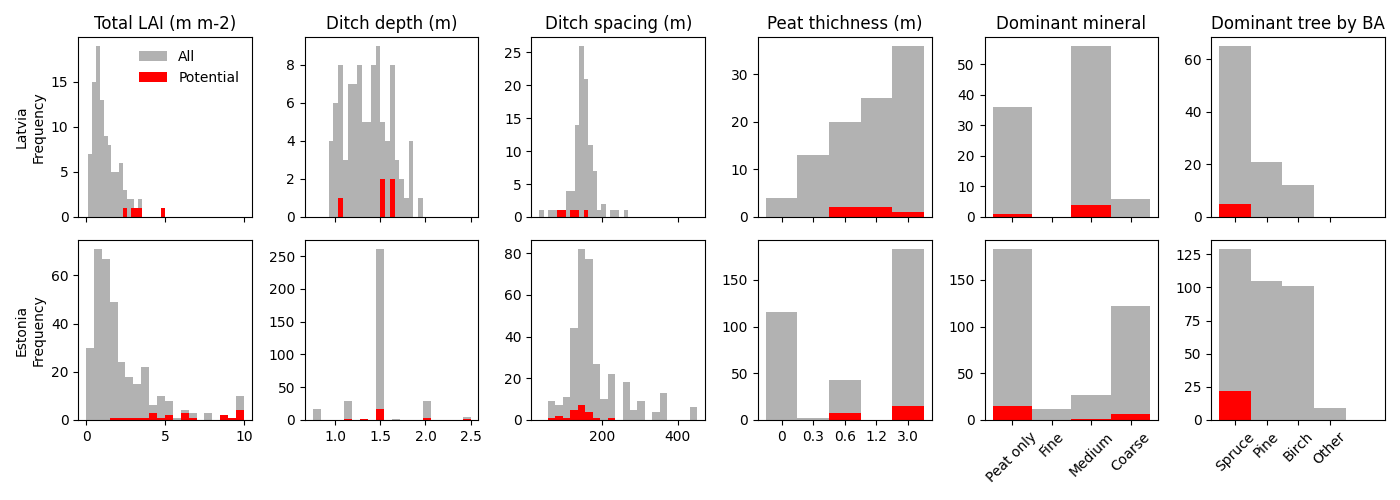

In [18]:
variables = [total_lai, ditch_depth, ditch_spacing, peat_layers, dominant_mineral_numeric, BA_max_label_numeric]
var_labels = ['Total LAI (m m-2)', 'Ditch depth (m)', 'Ditch spacing (m)', 'Peat thichness (m)', 'Dominant mineral', 'Dominant tree by BA']
# Latvia - Row 0

# Create figure with histograms
fig, axes = plt.subplots(2, len(variables), figsize=(14, 5), sharex='col')

for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_latvia].min()
        var_max = var[idx_latvia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[0, col].hist(var[idx_latvia], bins=bins, label='All', alpha= 0.6, color='grey')
    axes[0, col].hist(var[ix_latvia], bins=bins, label='Potential', color='red')
    if label == 'Dominant mineral':
        axes[0, col].set_xticks([0, 1, 2, 3])
        axes[0, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[0, col].set_xticks([0, 1, 2, 3, 4])
        axes[0, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[0, col].set_ylabel("Latvia\nFrequency")
        axes[0, col].legend(frameon=False)
    axes[0, col].set_title(f"{label}")

# Estonia - Row 1
for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_estonia].min()
        var_max = var[idx_estonia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[1, col].hist(var[idx_estonia], bins=bins, label='All', alpha= 0.6, color='grey')
    axes[1, col].hist(var[ix_estonia], bins=bins, label='Potential', color='red')
    if label == 'Dominant mineral':
        axes[1, col].set_xticks([0, 1, 2, 3])
        axes[1, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Dominant tree by BA':
        axes[1, col].set_xticks([0, 1, 2, 3])
        axes[1, col].set_xticklabels(['Spruce', 'Pine', 'Birch', 'Other'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[1, col].set_xticks([0, 1, 2, 3, 4])
        axes[1, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[1, col].set_ylabel("Estonia\nFrequency")

plt.tight_layout()

plt.savefig(project_folder / 'model_inputs' / 'figures' / 'histograms_potential.png', dpi=150, bbox_inches = 'tight')

#plt.show()

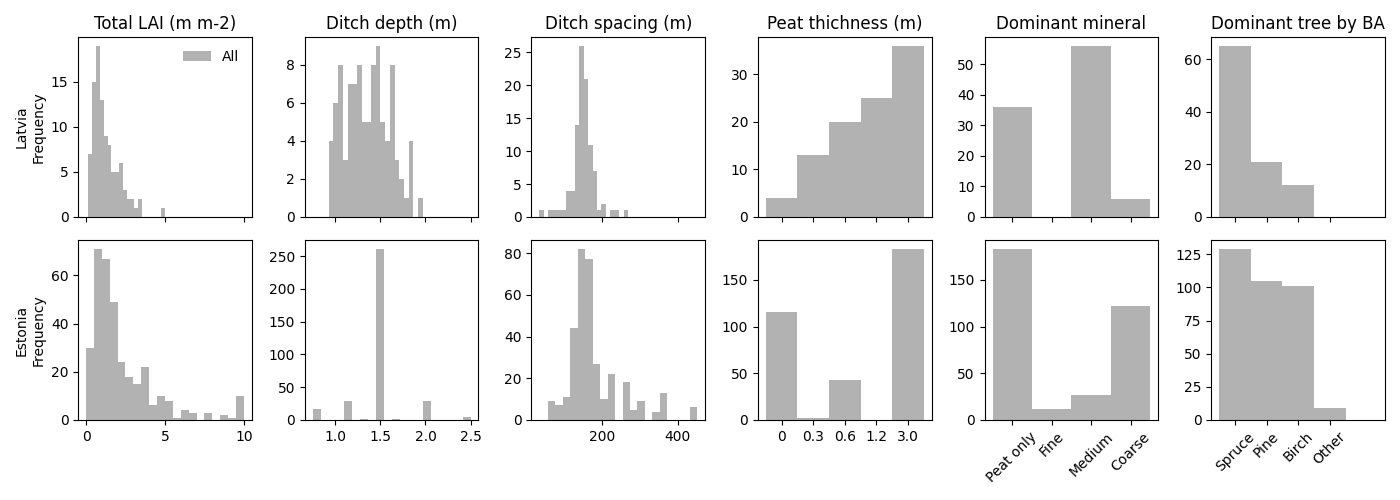

In [19]:
# Create figure with histograms

variables = [total_lai, ditch_depth, ditch_spacing, peat_layers, dominant_mineral_numeric, BA_max_label_numeric]
var_labels = ['Total LAI (m m-2)', 'Ditch depth (m)', 'Ditch spacing (m)', 'Peat thichness (m)', 'Dominant mineral', 'Dominant tree by BA']


fig, axes = plt.subplots(2, len(variables), figsize=(14, 5), sharex='col')
# Latvia - Row 0

for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_latvia].min()
        var_max = var[idx_latvia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[0, col].hist(var[idx_latvia], bins=bins, label='All', alpha= 0.6, color='grey')
    if label == 'Dominant mineral':
        axes[0, col].set_xticks([0, 1, 2, 3])
        axes[0, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[0, col].set_xticks([0, 1, 2, 3, 4])
        axes[0, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[0, col].set_ylabel("Latvia\nFrequency")
        axes[0, col].legend(frameon=False)
    axes[0, col].set_title(f"{label}")

# Estonia - Row 1
for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_estonia].min()
        var_max = var[idx_estonia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[1, col].hist(var[idx_estonia], bins=bins, label='All', alpha= 0.6, color='grey')
    if label == 'Dominant mineral':
        axes[1, col].set_xticks([0, 1, 2, 3])
        axes[1, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Dominant tree by BA':
        axes[1, col].set_xticks([0, 1, 2, 3])
        axes[1, col].set_xticklabels(['Spruce', 'Pine', 'Birch', 'Other'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[1, col].set_xticks([0, 1, 2, 3, 4])
        axes[1, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[1, col].set_ylabel("Estonia\nFrequency")

plt.tight_layout()

plt.savefig(project_folder / 'model_inputs' / 'figures' / 'histograms.png', dpi=150, bbox_inches = 'tight')

#plt.show()

In [20]:
LAI_df['Site_id'][ix.values].values

array([ 32,  36,  43, 106, 113, 150, 168, 172, 178, 180, 186, 194, 271,
       276, 286, 307, 336, 338, 358, 378, 382, 383])

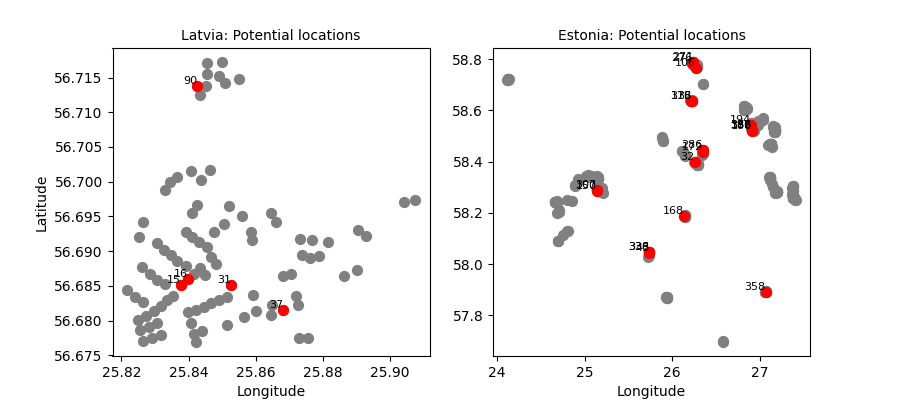

In [26]:
# Get lat/lon coordinates
lat = results['parameters_lat'][:,0]
lon = results['parameters_lon'][:,0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, idx, ix, country in zip(axes, [idx_latvia, idx_estonia], [ix_latvia, ix_estonia], ['Latvia', 'Estonia']):
    ax.scatter(lon[idx], lat[idx], c='grey', s=50)
    ax.scatter(lon[ix], lat[ix], c='red', s=50)
    for x,y,site_id in zip(lon[ix], lat[ix], LAI_df['Site_id'][ix.values].values):
        ax.text(x, y, str(site_id), fontsize=8, ha='right', va='bottom')
    ax.set_xlabel("Longitude")
    if country == 'Latvia':
        ax.set_ylabel("Latitude")
    ax.set_title(f"{country}: Potential locations", fontsize=10)

plt.savefig(project_folder / 'model_inputs' / 'figures' / 'scatter_potential_locations.png', dpi=150, bbox_inches = 'tight')
#plt.show()

LAI_df['total_lai'] = total_lai
LAI_df['ditch_depth'] = ditch_depth
LAI_df['ditch_spacing'] = ditch_spacing
LAI_df['peat_layers'] = peat_layers
LAI_df['dominant_mineral'] = dominant_mineral
LAI_df['DrySummerGWL_Current'] = real_q10
LAI_df['DrySummerGWL_Adapt'] = adapt_q10
LAI_df['Current_minus_Adapt'] = real_q10 - adapt_q10
cols = ['Site_id','lat','lon','BA','total_lai', 'BA_max_label','ditch_depth', 'ditch_spacing', 'peat_layers', 'dominant_mineral', 'DrySummerGWL_Current', 'DrySummerGWL_Adapt', 'Current_minus_Adapt']


LAI_df[cols].loc[idx_latvia].to_excel(project_folder / 'all_sites_latvia.xlsx', index=False)
LAI_df[cols].loc[idx_estonia].to_excel(project_folder / 'all_sites_estonia.xlsx', index=False)

LAI_df_selected_lat = LAI_df[cols].loc[(ix_latvia).values]
LAI_df_selected_est = LAI_df[cols].loc[(ix_estonia).values]

from scipy.spatial.distance import cdist

for df in (LAI_df_selected_lat, LAI_df_selected_est):
    # Extract coordinates
    coords = df[['lat', 'lon']].to_numpy()

    # 1. Euclidean distance in degrees
    dist_deg = cdist(coords, coords, metric='euclidean')

    # 2. Convert degrees → km using Earth radius scaling
    mean_lat = np.radians(df['lat'].mean())

    # Length of 1 degree at this latitude:
    km_per_degree = 111.32 * np.cos(mean_lat)   # adjusts for longitude shrinking

    dist_km = dist_deg * km_per_degree

    # Fill diagonal with big numbers so the closest is never itself
    np.fill_diagonal(dist_km, np.inf)

    # Identify index of closest site
    closest_idx = np.argmin(dist_km, axis=1)

    # Add results to DataFrame
    df['closest_site_id'] = df['Site_id'].iloc[closest_idx].values
    df['distance_to_closest'] = dist_km[np.arange(len(df)), closest_idx]

LAI_df_selected_lat.to_excel(project_folder / 'potential_sites_latvia.xlsx', index=False)
LAI_df_selected_est.to_excel(project_folder / 'potential_sites_estonia.xlsx', index=False)

In [27]:
LAI_df_selected_est

,Site_id,lat,lon,BA,total_lai,BA_max_label,ditch_depth,ditch_spacing,peat_layers,dominant_mineral,DrySummerGWL_Current,DrySummerGWL_Adapt,Current_minus_Adapt,closest_site_id,distance_to_closest
27,32,58.399694,26.255466,20.0,3.800288,spruce,2.500,167.875702,4,Peat_only,-0.721487,-0.486582,-0.234905,286,5.914423
30,36,58.638299,26.209915,29.0,6.185730,spruce,1.500,182.411667,4,Peat_only,-0.721143,-0.436768,-0.284375,378,0.736338
37,43,58.044149,25.735766,22.5,4.483554,spruce,2.000,128.109787,4,Peat_only,-0.772238,-0.516003,-0.256235,338,0.196499
100,106,58.765127,26.265559,20.1,2.419105,spruce,1.500,111.273605,2,Medium,-0.735277,-0.427603,-0.307674,271,2.267966
107,113,58.638685,26.224106,26.0,6.333510,spruce,1.500,82.573952,4,Peat_only,-0.789010,-0.567340,-0.221670,378,0.192813
142,150,58.285617,25.140793,21.2,2.567849,spruce,1.500,220.352554,2,Coarse,-0.824365,-0.312169,-0.512197,307,0.321582
160,168,58.186699,26.131759,27.1,10.000000,spruce,2.000,73.140999,2,Coarse,-1.917385,-0.840608,-1.076777,32,14.354734
164,172,58.439080,26.353332,22.4,1.612428,spruce,1.500,91.334213,2,Coarse,-1.220956,-0.285744,-0.935213,286,0.614857
169,178,58.522232,26.907891,27.7,6.002338,spruce,1.125,121.557732,2,Coarse,-1.107215,-0.632659,-0.474556,180,0.100042
171,180,58.520649,26.908555,28.6,10.000000,spruce,1.500,121.557732,2,Coarse,-1.328275,-0.700201,-0.628074,178,0.100042


In [22]:

summer_mean = summer.mean(dim='date')
real_mean = summer_mean.sel(j=0)
adapt_mean = summer_mean.sel(j=1)



summer_site_mean = summer.mean(dim='i')
summer_site_low = summer.quantile(0.25, dim='i')
summer_site_high = summer.quantile(0.75, dim='i')

summer_climatology = summer_site_mean.groupby('date.dayofyear').mean(dim='date')
summer_climatology_low = summer_site_low.groupby('date.dayofyear').mean(dim='date')
summer_climatology_high = summer_site_high.groupby('date.dayofyear').mean(dim='date')

real_clim = summer_climatology.sel(j=0)
real_clim_low = summer_climatology_low.sel(j=0)
real_clim_high = summer_climatology_high.sel(j=0)

adapt_clim = summer_climatology.sel(j=1)
adapt_clim_low = summer_climatology_low.sel(j=1)
adapt_clim_high = summer_climatology_high.sel(j=1)

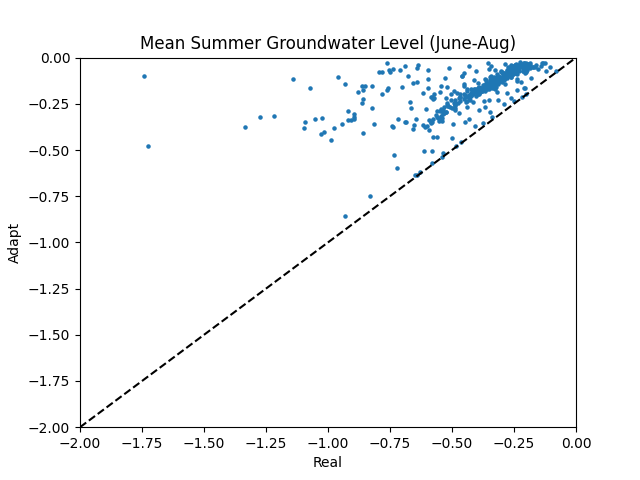

In [23]:
plt.figure()
plt.scatter(real_mean, adapt_mean, s=5)
plt.axline((0, 0), slope=1, linestyle='--', color='black')  # 1:1 line
plt.xlabel("Real")
plt.ylabel("Adapt")
plt.title("Mean Summer Groundwater Level (June-Aug)")
plt.ylim([-2.,0.])
plt.xlim([-2.,0.])
plt.show()

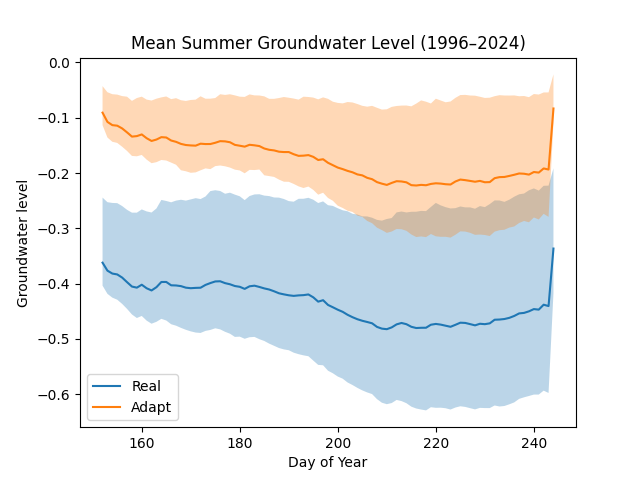

In [24]:
import matplotlib.pyplot as plt

# x-axis (day of year)
x = real_clim['dayofyear'].values

plt.figure()

# --- Real ---
plt.plot(x, real_clim.values, label="Real")
plt.fill_between(
    x,
    real_clim_low.values,
    real_clim_high.values,
    alpha=0.3
)

# --- Adapt ---
plt.plot(x, adapt_clim.values, label="Adapt")
plt.fill_between(
    x,
    adapt_clim_low.values,
    adapt_clim_high.values,
    alpha=0.3
)

plt.legend()
plt.title("Mean Summer Groundwater Level (1996–2024)")
plt.ylabel("Groundwater level")
plt.xlabel("Day of Year")
plt.show()